<a href="https://colab.research.google.com/github/Shahd132/CNN-Architecture-Optimizers-Transfer-Learning/blob/main/CNN_Architecture%2C_Optimizers%2C_Transfer_Learning_V2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Starter Code

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import time
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
# CIFAR-10 Class Names
CLASS_NAMES = ['airplane','automobile','bird','cat','deer',
 'dog','frog','horse','ship','truck']
# Load Data
(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()
# Fixed Split: 40,000 train / 10,000 val / 10,000 test
x_train = x_train_full[:40000].astype('float32')
y_train = y_train_full[:40000]
x_val = x_train_full[40000:].astype('float32')
y_val = y_train_full[40000:]
x_test = x_test.astype('float32')
print(f"Train: {x_train.shape} | Val: {x_val.shape} | Test: {x_test.shape}")
print(f"Pixel range: [{x_train.min()}, {x_train.max()}]")
print(f"Image shape: {x_train[0].shape}")


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 30s 0us/step
Train: (40000, 32, 32, 3) | Val: (10000, 32, 32, 3) | Test: (10000, 32, 32, 3)
Pixel range: [0.0, 255.0]
Image shape: (32, 32, 3)


### Helper Functions

In [6]:
def train_and_evaluate(model, x_tr, y_tr, x_v, y_v, x_te, y_te,
                      epochs=20, batch_size=128, extra_callbacks=None):
    cb = extra_callbacks if extra_callbacks else []
    start = time.time()

    history = model.fit(x_tr, to_categorical(y_tr, 10),
                        validation_data=(x_v, to_categorical(y_v, 10)),
                        epochs=epochs, batch_size=batch_size,
                        callbacks=cb, verbose=0)

    elapsed = time.time() - start

    test_loss, test_acc = model.evaluate(x_te, to_categorical(y_te, 10), verbose=0)

    print(f"Test Acc: {test_acc:.4f} | Test Loss: {test_loss:.4f} | Time: {elapsed:.1f}s")

    return history, test_acc, test_loss, elapsed


def plot_curves(histories, labels, metric='val_accuracy', title='', ylabel=''):
    plt.figure(figsize=(10, 6))

    for h, lbl in zip(histories, labels):
        plt.plot(h.history[metric], label=lbl)

    plt.xlabel('Epoch')
    plt.ylabel(ylabel if ylabel else metric)
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

In [8]:
# TEMP: assume standardized data (until Member 1 gives exact version)
x_train_std = x_train / 255.0
x_val_std   = x_val / 255.0
x_test_std  = x_test / 255.0

## Task 1A

# **Build Baseline CNN**

In [ ]:

# This function builds the same CNN architecture used in all 3 normalization experiments

def build_baseline_cnn():
    model = models.Sequential([
        # First convolution layer
        layers.Conv2D(32, (3, 3), activation='relu',
                      padding='same', input_shape=(32, 32, 3)),

        # First pooling layer
        layers.MaxPooling2D((2, 2)),

        # Second convolution layer
        layers.Conv2D(64, (3, 3), activation='relu',
                      padding='same'),

        # Second pooling layer
        layers.MaxPooling2D((2, 2)),

        # Convert feature maps into 1D vector
        layers.Flatten(),

        # Fully connected hidden layer
        layers.Dense(128, activation='relu'),

        # Output layer for 10 classes
        layers.Dense(10, activation='softmax')
    ])

    # Compile the model
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
# Task 1A - Data Preprocessing Experiments

# Experiment A: No normalization
x_train_raw = x_train.copy()
x_val_raw = x_val.copy()
x_test_raw = x_test.copy()

# Experiment B: Min-Max normalization
x_train_minmax = x_train / 255.0
x_val_minmax = x_val / 255.0
x_test_minmax = x_test / 255.0

# Experiment C: Standardization using training set statistics only
mean = np.mean(x_train, axis=(0, 1, 2))
std = np.std(x_train, axis=(0, 1, 2))

x_train_std = (x_train - mean) / std
x_val_std = (x_val - mean) / std
x_test_std = (x_test - mean) / std

In [ ]:
# Task 1A - Train the model on all 3 preprocessing methods

histories = []
labels = []
results = []

experiments = [
    ("Raw", x_train_raw, x_val_raw, x_test_raw),
    ("Min-Max", x_train_minmax, x_val_minmax, x_test_minmax),
    ("Standardized", x_train_std, x_val_std, x_test_std)
]

for label, x_tr, x_v, x_te in experiments:
    print(f"\nTraining model with {label} preprocessing...")

    model = build_baseline_cnn()

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model,
        x_tr, y_train,
        x_v, y_val,
        x_te, y_test,
        epochs=20,
        batch_size=128
    )

    histories.append(history)
    labels.append(label)

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    loss_epoch1 = history.history['loss'][0]

    results.append({
        "Preprocessing": label,
        "Train Acc": train_acc,
        "Val Acc": val_acc,
        "Test Acc": test_acc,
        "Loss @ Epoch 1": loss_epoch1
    })


Training model with Raw preprocessing...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.5553 | Test Loss: 2.8616 | Time: 48.1s

Training model with Min-Max preprocessing...
Test Acc: 0.6708 | Test Loss: 1.2236 | Time: 45.4s

Training model with Standardized preprocessing...
Test Acc: 0.6691 | Test Loss: 2.0193 | Time: 45.4s


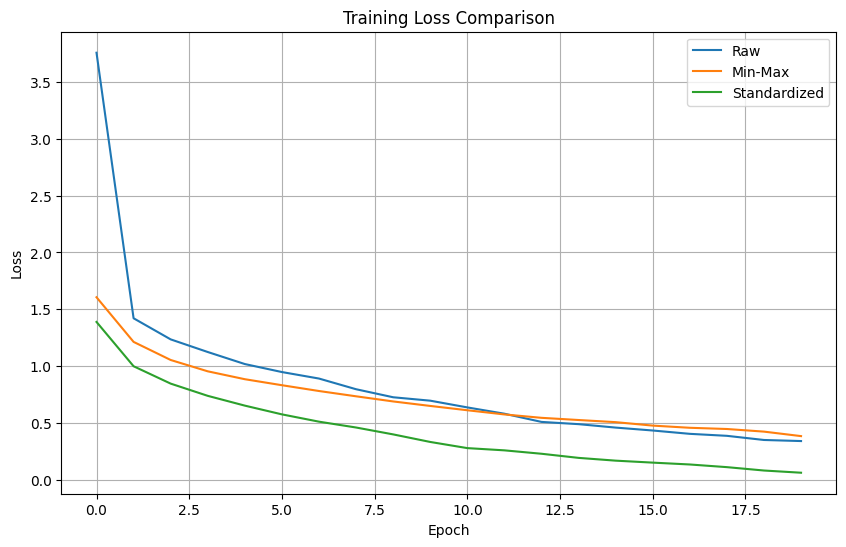

In [ ]:
# Plot training loss curves for all experiments
plot_curves(
    histories,
    labels,
    metric='loss',
    title='Training Loss Comparison',
    ylabel='Loss'
)

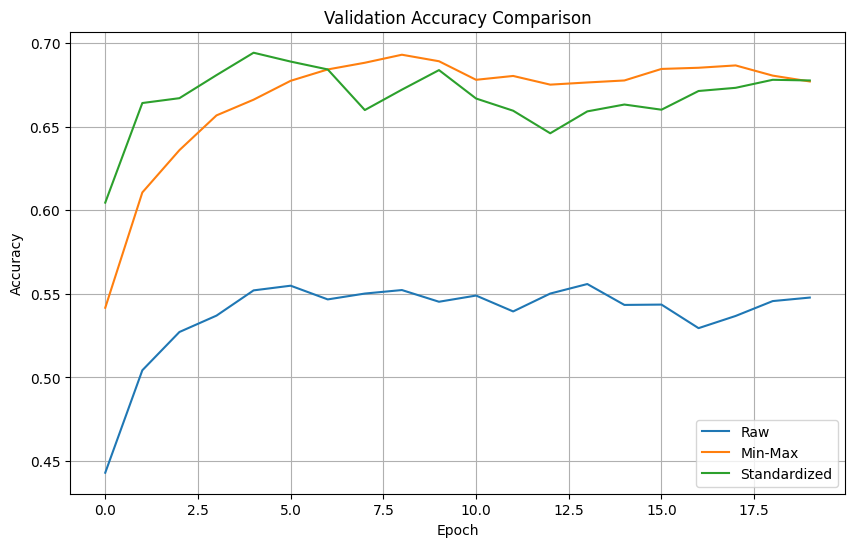

In [ ]:
# Plot validation accuracy curves for all experiments
plot_curves(
    histories,
    labels,
    metric='val_accuracy',
    title='Validation Accuracy Comparison',
    ylabel='Accuracy'
)

In [ ]:
# Display results table
import pandas as pd

results_df = pd.DataFrame(results)
results_df

,Preprocessing,Train Acc,Val Acc,Test Acc,Loss @ Epoch 1
0,Raw,0.882725,0.5478,0.5553,3.756879
1,Min-Max,0.867375,0.6771,0.6708,1.605673
2,Standardized,0.980175,0.6777,0.6691,1.388406


**The results show that both Min-Max normalization and standardization lead to a substantial improvement over raw pixel inputs. Interestingly, both techniques achieved nearly identical test accuracy, suggesting that the model is relatively insensitive to the specific scaling method as long as the input is properly normalized. In contrast, the raw input resulted in significantly lower performance, highlighting the importance of preprocessing for effective convergence and generalization.**

## Task 1B

Setup **Augmentation**

In [ ]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

datagen.fit(x_train_std)

**Experiment 1 (NO Augmentation)**

In [ ]:
def build_baseline_cnn():
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(32,32,3)),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [ ]:
model_no_aug = build_baseline_cnn()

history_no_aug, test_acc_no_aug, _, _ = train_and_evaluate(
    model_no_aug,
    x_train_std, y_train,
    x_val_std, y_val,
    x_test_std, y_test,
    epochs=40,
    batch_size=128
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.6705 | Test Loss: 3.3262 | Time: 89.8s


**Experiment 2 (WITH Augmentation)**

In [ ]:
model_aug = build_baseline_cnn()

history_aug = model_aug.fit(
    datagen.flow(x_train_std, to_categorical(y_train, 10), batch_size=128),
    validation_data=(x_val_std, to_categorical(y_val, 10)),
    epochs=40,
    verbose=1
)

test_loss_aug, test_acc_aug = model_aug.evaluate(
    x_test_std, to_categorical(y_test, 10), verbose=0
)

Epoch 1/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 83ms/step - accuracy: 0.4449 - loss: 1.5442 - val_accuracy: 0.5741 - val_loss: 1.2199
Epoch 2/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - accuracy: 0.5709 - loss: 1.2186 - val_accuracy: 0.6240 - val_loss: 1.0922
Epoch 3/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.6165 - loss: 1.0918 - val_accuracy: 0.6386 - val_loss: 1.0499
Epoch 4/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 77ms/step - accuracy: 0.6430 - loss: 1.0169 - val_accuracy: 0.6591 - val_loss: 0.9717
Epoch 5/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.6626 - loss: 0.9560 - val_accuracy: 0.6552 - val_loss: 1.0264
Epoch 6/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 77ms/step - accuracy: 0.6762 - loss: 0.9186 - val_accuracy: 0.6941 - val_loss: 0.8753
Epoch 7/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.6894 - loss: 0.8808 - val_accuracy: 0.6984 - val_loss: 0.8687
Epoch 8/40
313/313 ━━━━━━━━━━━━━━━━━━━━ 24s 76ms/step - accuracy: 0.7002 - loss: 0.8531 - 

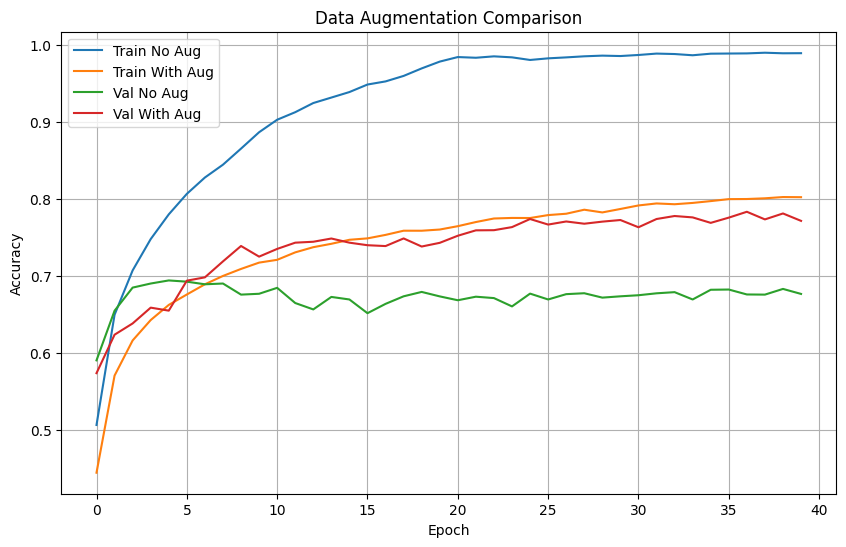

In [ ]:
plt.figure(figsize=(10,6))

# Train accuracy
plt.plot(history_no_aug.history['accuracy'], label='Train No Aug')
plt.plot(history_aug.history['accuracy'], label='Train With Aug')

# Val accuracy
plt.plot(history_no_aug.history['val_accuracy'], label='Val No Aug')
plt.plot(history_aug.history['val_accuracy'], label='Val With Aug')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Data Augmentation Comparison")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
gap_no_aug = history_no_aug.history['accuracy'][-1] - history_no_aug.history['val_accuracy'][-1]
gap_aug = history_aug.history['accuracy'][-1] - history_aug.history['val_accuracy'][-1]

print("Overfitting Gap (No Aug):", gap_no_aug)
print("Overfitting Gap (With Aug):", gap_aug)

Overfitting Gap (No Aug): 0.31237494945526123
Overfitting Gap (With Aug): 0.03072500228881836


**Data augmentation significantly reduced overfitting by increasing training data diversity. The model trained with augmentation shows a smaller gap between training and validation accuracy compared to the model without augmentation. This indicates better generalization and improved robustness to unseen data.**

### Task 2A

In [11]:
def build_cnn_filters(f1, f2, f3, f4):
    model = models.Sequential([
        layers.Conv2D(f1, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
        layers.Conv2D(f2, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Conv2D(f3, (3,3), activation='relu', padding='same'),
        layers.Conv2D(f4, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D((2,2)),

        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

In [ ]:
configs = {
    "Small":  (8, 8, 16, 16),
    "Medium": (32, 32, 64, 64),
    "Large":  (64, 64, 128, 128)
}

histories = []
labels = []
results = []

for name, (f1, f2, f3, f4) in configs.items():
    print(f"\nTraining {name} model...")

    model = build_cnn_filters(f1, f2, f3, f4)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    model.summary()

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test
    )

    histories.append(history)
    labels.append(name)

    results.append([name, test_acc, elapsed])


Training Small model...


C:\Users\shahd\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 8)      │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 8)      │           584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 269,266 (1.03 MB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     2,097,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,360,138 (9.00 MB)

 Trainable params: 2,360,138 (9.00 MB)

 Non-trainable params: 0 (0.00 B)

Test Acc: 0.7119 | Test Loss: 2.0459 | Time: 2864.1s


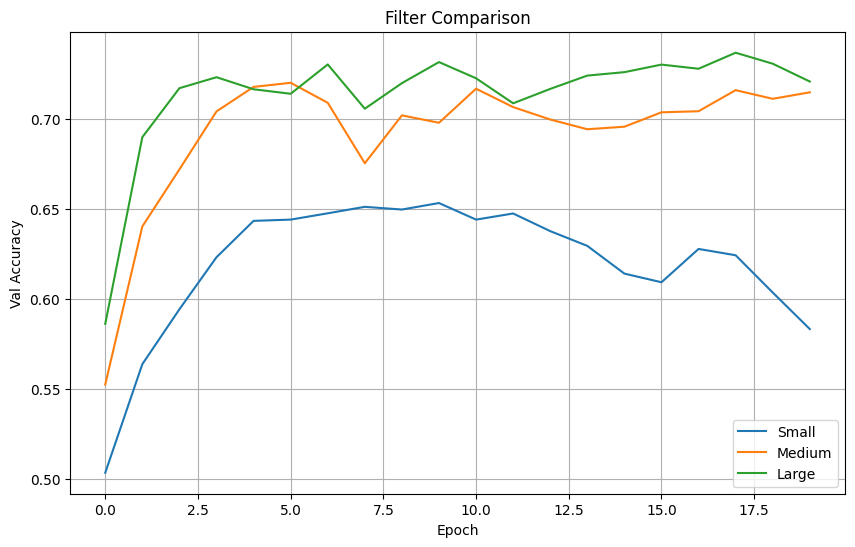

In [ ]:
plot_curves(histories, labels, metric='val_accuracy', title='Filter Comparison', ylabel='Val Accuracy')

### Task 2C

In [2]:
def build_depth_model(depth_type):
    model = models.Sequential()
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
    model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D((2,2)))

    if depth_type in ['medium', 'deep']:
        model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
        model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
        model.add(layers.MaxPooling2D((2,2)))

    if depth_type == 'deep':
        model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
        model.add(layers.Conv2D(32, (3,3), activation='relu', padding='same'))
        model.add(layers.MaxPooling2D((2,2)))

    if depth_type == 'shallow':
        model.add(layers.Flatten())
    else:
        model.add(layers.GlobalAveragePooling2D())

    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    return model

In [9]:
depths = ['shallow', 'medium', 'deep']

for d in depths:
    print(f"\nTraining {d} model...")
    model = build_depth_model(d)

    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test
    )


Training shallow model...
Test Acc: 0.6391 | Test Loss: 2.4781 | Time: 59.5s

Training medium model...
Test Acc: 0.6592 | Test Loss: 0.9562 | Time: 68.3s

Training deep model...
Test Acc: 0.7037 | Test Loss: 0.8648 | Time: 71.3s


### Task 4A

In [ ]:
optimizers = {
    'SGD': keras.optimizers.SGD(learning_rate=0.001),
    'Momentum': keras.optimizers.SGD(learning_rate=0.001, momentum=0.9),
    'AdaGrad': keras.optimizers.Adagrad(learning_rate=0.001),
    'RMSProp': keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam': keras.optimizers.Adam(learning_rate=0.001)
}

for name, opt in optimizers.items():
    print(f"\nTraining with {name}")

    model = build_cnn_filters(32,32,64,64)  # Medium model

    model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test
    )


Training with SGD
Test Acc: 0.3835 | Test Loss: 1.7783 | Time: 684.5s

Training with Momentum
Test Acc: 0.6022 | Test Loss: 1.1522 | Time: 735.7s

Training with AdaGrad
Test Acc: 0.4591 | Test Loss: 1.5112 | Time: 710.2s

Training with RMSProp
Test Acc: 0.6893 | Test Loss: 2.7650 | Time: 802.5s

Training with Adam
Test Acc: 0.7105 | Test Loss: 2.2362 | Time: 825.6s


### Task 4B

In [12]:
lrs = [0.0001, 0.001, 0.01]

for lr in lrs:
    print(f"\nTraining with LR = {lr}")

    model = build_cnn_filters(32,32,64,64)

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model, x_train_std, y_train, x_val_std, y_val, x_test_std, y_test
    )


Training with LR = 0.0001
Test Acc: 0.6833 | Test Loss: 0.9319 | Time: 79.8s

Training with LR = 0.001
Test Acc: 0.7011 | Test Loss: 2.2920 | Time: 78.1s

Training with LR = 0.01
Test Acc: 0.1000 | Test Loss: 2.3032 | Time: 74.6s


## Task 3A

In [ ]:
def build_medium_model(dropout_rate=0.0):

    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', padding='same',
                      input_shape=(32,32,3)),
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.MaxPooling2D(2,2),

        layers.Flatten(),

        # Dropout controlled here
        layers.Dropout(dropout_rate),

        layers.Dense(256, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
dropout_settings = {
    "D0": 0.0,
    "D1": 0.25,
    "D2": 0.5
}

histories = []
labels = []
results = []

for name, rate in dropout_settings.items():
    print(f"\nTraining {name} with dropout = {rate}")

    model = build_medium_model(dropout_rate=rate)

    history, test_acc, _, _ = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test,
        epochs=30,
        batch_size=128
    )

    histories.append(history)
    labels.append(name)

    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]

    results.append({
        "Model": name,
        "Train Acc": train_acc,
        "Val Acc": val_acc,
        "Test Acc": test_acc,
        "Overfit Gap": train_acc - val_acc
    })


Training D0 with dropout = 0.0
Test Acc: 0.7163 | Test Loss: 2.5914 | Time: 118.0s

Training D1 with dropout = 0.25
Test Acc: 0.7518 | Test Loss: 1.5149 | Time: 118.1s

Training D2 with dropout = 0.5
Test Acc: 0.7649 | Test Loss: 0.9893 | Time: 118.9s


In [ ]:
import pandas as pd
pd.DataFrame(results)

,Model,Train Acc,Val Acc,Test Acc,Overfit Gap
0,D0,0.987375,0.7219,0.7163,0.265475
1,D1,0.979450,0.7566,0.7518,0.222850
2,D2,0.952650,0.7721,0.7649,0.180550


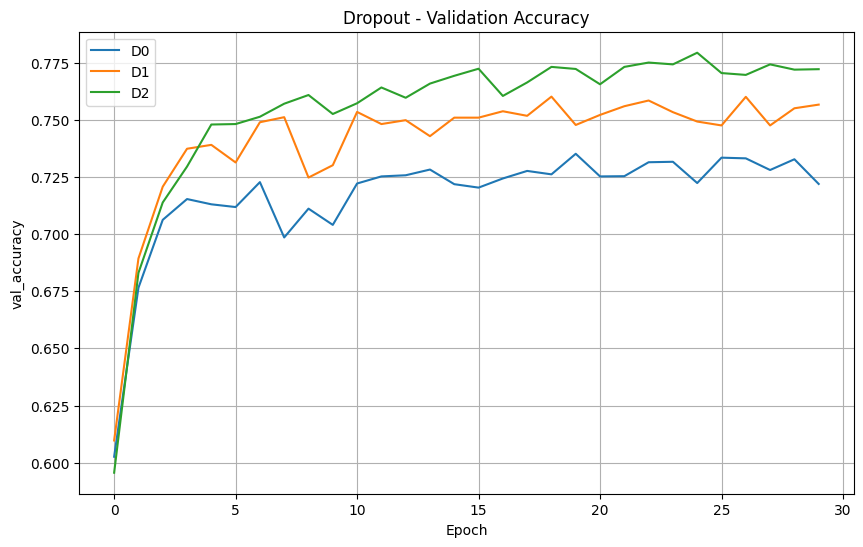

In [ ]:
plot_curves(histories, list(dropout_settings.keys()),
            metric='val_accuracy',
            title='Dropout - Validation Accuracy')

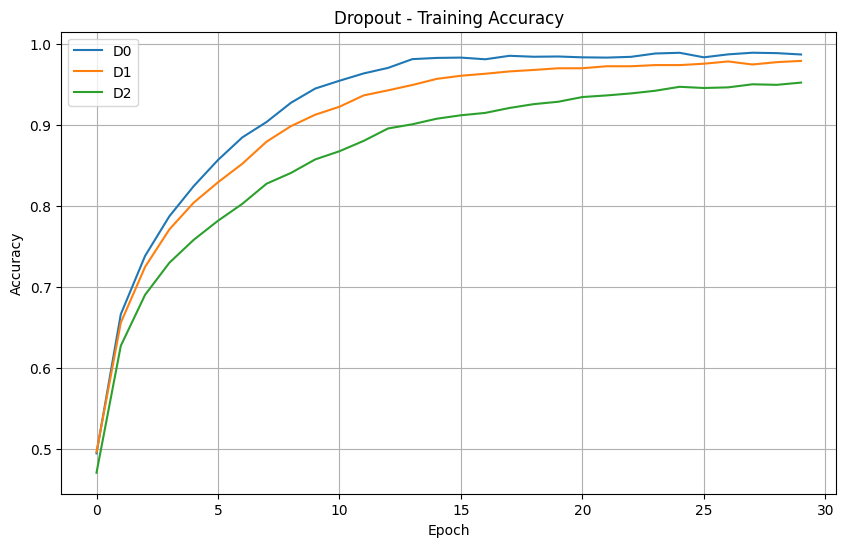

In [ ]:
plt.figure(figsize=(10,6))

for h, label in zip(histories, labels):
    plt.plot(h.history['accuracy'], label=label)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Dropout - Training Accuracy")
plt.legend()
plt.grid(True)
plt.show()

**Dropout improved generalization by reducing overfitting. The model without dropout achieved the highest training accuracy but showed a larger gap between training and validation accuracy, indicating overfitting. Higher dropout (0.5) reduced overfitting further but slightly decreased overall performance. The best trade-off was achieved with moderate dropout (0.25), which provided strong test accuracy with a smaller generalization gap.**

## 3B

In [ ]:
def train_with_early_stopping(patience, epochs=50):

    es = callbacks.EarlyStopping(
        monitor='val_loss',
        patience=patience,
        restore_best_weights=True
    )

    model = build_medium_model(dropout_rate=0.0)

    history, test_acc, test_loss, elapsed = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test,
        epochs=epochs,
        batch_size=128,
        extra_callbacks=[es]
    )

    return history, test_acc, test_loss, elapsed, len(history.history['loss'])

In [ ]:
es_results = []

configs = {
    "ES0": None,
    "ES2": 5,
    "ES3": 10
}

histories_es = []
labels_es = []

for name, patience in configs.items():

    if patience is None:
        es = []
        epochs = 50
    else:
        es = [callbacks.EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True
        )]
        epochs = 50

    model = build_medium_model(dropout_rate=0.0)

    history, test_acc, _, elapsed = train_and_evaluate(
        model,
        x_train_std, y_train,
        x_val_std, y_val,
        x_test_std, y_test,
        epochs=epochs,
        batch_size=128,
        extra_callbacks=es
    )

    histories_es.append(history)
    labels_es.append(name)

    best_val = min(history.history['val_loss'])
    stopped_epoch = len(history.history['loss'])

    es_results.append({
        "Experiment": name,
        "Stopped Epoch": stopped_epoch,
        "Best Val Loss": best_val,
        "Test Acc": test_acc,
        "Time": elapsed
    })

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Test Acc: 0.7171 | Test Loss: 3.1717 | Time: 188.8s
Test Acc: 0.7135 | Test Loss: 0.8622 | Time: 39.8s
Test Acc: 0.7046 | Test Loss: 0.8499 | Time: 53.9s


In [ ]:
pd.DataFrame(es_results)

,Experiment,Stopped Epoch,Best Val Loss,Test Acc,Time
0,ES0,50,0.891739,0.7171,188.840863
1,ES2,9,0.831120,0.7135,39.783008
2,ES3,13,0.838103,0.7046,53.862667


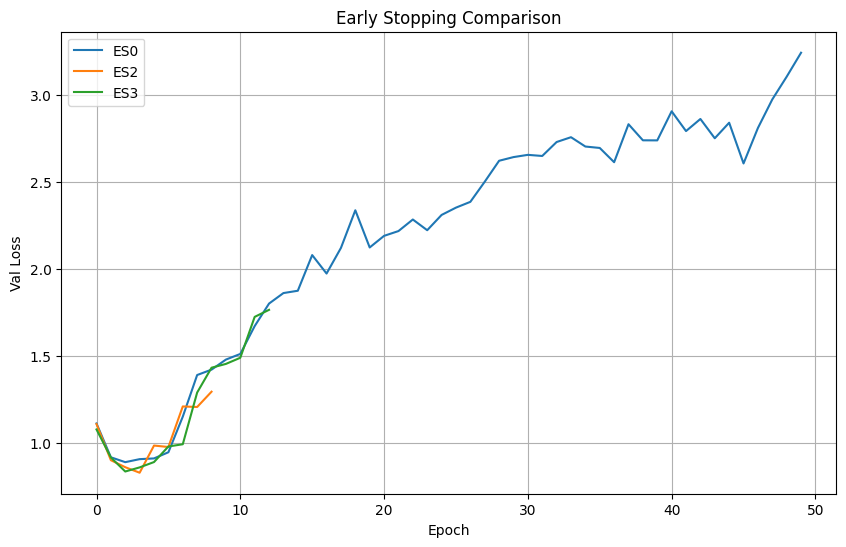

In [ ]:
plt.figure(figsize=(10,6))

for h, label in zip(histories_es, labels_es):
    plt.plot(h.history['val_loss'], label=label)

plt.xlabel("Epoch")
plt.ylabel("Val Loss")
plt.title("Early Stopping Comparison")
plt.legend()
plt.grid(True)
plt.show()

**The results show that the model without early stopping (ES0) achieved the highest test accuracy but required significantly more training time and exhibited signs of overfitting. Early stopping with patience=5 (ES2) reduced training time drastically while maintaining comparable performance, indicating a good balance between efficiency and generalization. In contrast, patience=10 (ES3) did not improve performance and resulted in slightly lower accuracy. Overall, ES2 provides the best trade-off between training efficiency and model performance.**